In [8]:
# STA 4724 Project
# Matheus Santos Gomes
# K-Nearest Neighbors(KNN)

In [56]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.neighbors import NearestNeighbors
from sklearn import neighbors 
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, confusion_matrix

In [57]:
# Reading the Dataset
file_path = "/Users/matheusmsgomes/Documents/Big Data Analytics/Project/Sleep_health_and_lifestyle_dataset.csv"
df = pd.read_csv(file_path)

In [58]:
# Dropping Person ID columns
df = df.drop(columns=["Person ID"])

# Making a Copy
df2 = df.copy()

# Map NaN target to a class label
df2["Sleep Disorder"] = df2["Sleep Disorder"].fillna("No Disorder")

# Defining the variables
Y = df2["Sleep Disorder"]         
X = df2.drop(columns=["Sleep Disorder"])

# Splitting the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y) #fraction of the dataset. 0.2 → 20% test, 80% train

In [59]:
# Split "Blood Pressure" into numeric cols
bp = df["Blood Pressure"].str.split("/", expand=True).rename(columns={0:"Systolic", 1:"Diastolic"})
bp = bp.apply(pd.to_numeric, errors="coerce")
df = pd.concat([df.drop(columns=["Blood Pressure"]), bp], axis=1)

In [60]:
# Normalizing features
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps",
    "Systolic",
    "Diastolic"
]

# Keep only the columns that exist in your dataset (safe check)
numeric_cols = [col for col in numeric_cols if col in X_train.columns]

scaler = StandardScaler()

# Fit only on training data
scaler.fit(X_train[numeric_cols])

# Transform both train and test sets
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[numeric_cols] = scaler.transform(X_train[numeric_cols])
X_test_scaled[numeric_cols]  = scaler.transform(X_test[numeric_cols])

# Checking it out
print("Scaled numeric features:")
print(X_train_scaled[numeric_cols].describe().round(2).T)

Scaled numeric features:
                         count  mean  std   min   25%   50%   75%   max
Age                      299.0   0.0  1.0 -1.78 -0.73  0.09  0.90  1.95
Sleep Duration           299.0  -0.0  1.0 -1.70 -0.87  0.08  0.84  1.72
Quality of Sleep         299.0   0.0  1.0 -2.81 -1.12 -0.27  0.58  1.42
Physical Activity Level  299.0  -0.0  1.0 -1.43 -0.70  0.02  0.74  1.46
Stress Level             299.0   0.0  1.0 -1.36 -0.79 -0.22  0.92  1.49
Heart Rate               299.0   0.0  1.0 -1.26 -0.51 -0.00  0.50  3.78
Daily Steps              299.0   0.0  1.0 -2.40 -0.54  0.08  0.70  1.94


In [61]:
# Grid Search for best K
# Pipeline: scale -> KNN  

# Identify columns
num_cols = X_train.select_dtypes(include=["number"]).columns
cat_cols = X_train.select_dtypes(exclude=["number"]).columns

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# ColumnTransformer (this must be an object, not a tuple/list)
preprocess = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
    ],
    remainder="drop"
)

pipe = Pipeline([
    ("prep", preprocess),
    ("knn", KNeighborsClassifier(metric="euclidean"))
])

# Hyperparameter Grid
k_neighbors = list(range(1, 21, 2))  # 1,3,5,...,19
param_grid = {
    "knn__n_neighbors": k_neighbors,
    "knn__weights": ["uniform", "distance"],  
}

# 10 fold stratified CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Grid search
gs = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
)

gs.fit(X_train, y_train)

best_k = gs.best_params_["knn__n_neighbors"]
print("Best k:", best_k)
print("Best params:", gs.best_params_)
print("Best CV accuracy:", round(gs.best_score_, 4))
print("Test accuracy with best model:", round(gs.score(X_test, y_test), 4))

Best k: 11
Best params: {'knn__n_neighbors': 11, 'knn__weights': 'uniform'}
Best CV accuracy: 0.8726
Test accuracy with best model: 0.92


In [63]:
# Evaluating
# CV accuracy
print("Best CV accuracy:", round(gs.best_score_, 4))
print("Test accuracy with best model:", round(gs.score(X_test, y_test), 4))

# Finding y_pred
best_model = gs.best_estimator_
y_pred = best_model.predict(X_test)

# Confusion Matrix
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))

# Classification Report
print("\nClassification report:\n", classification_report(y_test, y_pred, digits=3))

Best CV accuracy: 0.8726
Test accuracy with best model: 0.92

Confusion matrix:
 [[12  1  2]
 [ 1 43  0]
 [ 0  2 14]]

Classification report:
               precision    recall  f1-score   support

    Insomnia      0.923     0.800     0.857        15
 No Disorder      0.935     0.977     0.956        44
 Sleep Apnea      0.875     0.875     0.875        16

    accuracy                          0.920        75
   macro avg      0.911     0.884     0.896        75
weighted avg      0.920     0.920     0.919        75



Train accuracy: 0.8762541806020067
Test accuracy: 0.92
AUC for class 'Insomnia': 0.988
AUC for class 'No Disorder': 0.995
AUC for class 'Sleep Apnea': 0.990

Macro-average AUC: 0.991


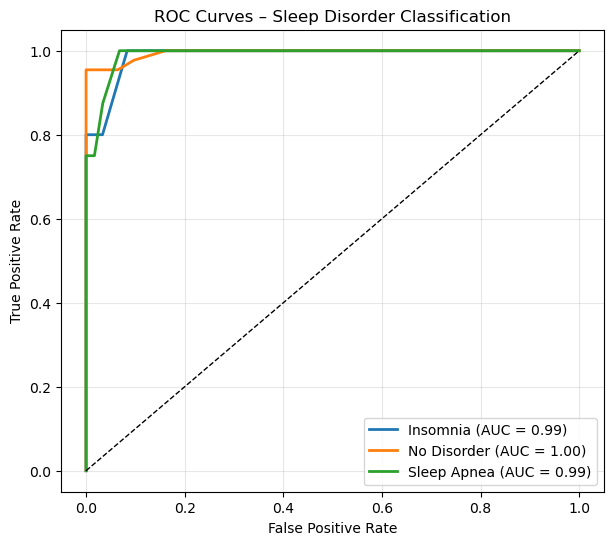

In [66]:
# ROC / AUC
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

best_model = gs.best_estimator_

y_score = best_model.predict_proba(X_test)

# Checking if model is not overfitting
print("Train accuracy:", best_model.score(X_train, y_train))
print("Test accuracy:", best_model.score(X_test, y_test))

# --- Binarize the target (convert classes -> 0/1 columns)
classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)

# --- Compute ROC curve and AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i, cls in enumerate(classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# --- Compute macro-average AUC
roc_auc["macro"] = roc_auc_score(y_test_bin, y_score, average="macro")

# --- Print numeric results
for i, cls in enumerate(classes):
    print(f"AUC for class '{cls}': {roc_auc[i]:.3f}")
print(f"\nMacro-average AUC: {roc_auc['macro']:.3f}")

# --- Plot ROC curves
plt.figure(figsize=(7, 6))
for i, cls in enumerate(classes):
    plt.plot(fpr[i], tpr[i], lw=2,
             label=f"{cls} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves – Sleep Disorder Classification")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()
